In [16]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
pplt.rc['reso']='xx-hi'
pplt.rc['figure.dpi'] = 100
warnings.filterwarnings('ignore')

In [17]:
with open('/global/cfs/cdirs/m4334/sferrett/monsoon-kernels/scripts/nn/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
FILEDIR    = CONFIGS['paths']['filedir']    
MODELDIR   = CONFIGS['paths']['modeldir']
RESULTSDIR = CONFIGS['paths']['resultsdir']
MODELS     = CONFIGS['models']

SPLIT      = 'valid'   
PRTHRESH   = 0.01
LANDTHRESH = 0.5
landfrac   = xr.open_dataarray('/global/cfs/cdirs/m4334/sferrett/monsoon-discovery/data/interim/lf.nc')

In [18]:
with xr.open_dataset(os.path.join(FILEDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truepr = ds.pr.load()

results = {}
for model in MODELS:
    name,description = model['name'],model['description']
    filename = f'{name}_{SPLIT}_pr.nc'
    filepath = os.path.join(RESULTSDIR,filename)
    if os.path.exists(filepath):
        with xr.open_dataset(filepath,engine='h5netcdf') as ds:
            predpr = ds.pr.load()
        ytrue,ypred = xr.align(truepr,predpr,join='inner')
        results[name] = dict(description=description,ytrue=ytrue,ypred=ypred)
print(f'Found {len(results)} completed models for `{SPLIT}`')

nrows = 2
ncols = 4

Found 7 completed models for `valid`


In [19]:
def get_r2(ytrue,ypred,dims=None,landfrac=None,landthresh=LANDTHRESH):
    dims = list(ytrue.dims) if dims is None else dims
    if landfrac is not None:
        r2values = []
        for mask in [landfrac>=landthresh,landfrac<landthresh]:
            ssres = ((ytrue.where(mask)-ypred.where(mask))**2).sum(dim=dims,skipna=True)
            sstot = ((ytrue.where(mask)-ytrue.where(mask).mean(dim=dims,skipna=True))**2).sum(dim=dims,skipna=True)
            r2values.append(1-ssres/sstot)
        return tuple(r2values)
    ssres = ((ytrue-ypred)**2).sum(dim=dims,skipna=True)
    sstot = ((ytrue-ytrue.mean(dim=dims,skipna=True))**2).sum(dim=dims,skipna=True)
    return 1-ssres/sstot
    
def get_confusion_matrix(ytrue,ypred,dims=None,prthresh=PRTHRESH):
    dims = list(ytrue.dims) if dims is None else dims
    ytrueabove = ytrue>prthresh
    ypredabove = ypred>prthresh
    tp = (ypredabove&ytrueabove).sum(dim=dims,skipna=True)
    tn = (~ypredabove&~ytrueabove).sum(dim=dims,skipna=True)
    fp = (ypredabove&~ytrueabove).sum(dim=dims,skipna=True)
    fn = (~ypredabove&ytrueabove).sum(dim=dims,skipna=True)
    if dims==list(ytrue.dims) and 'member' not in ypred.dims:
        return int(tp),int(fp),int(fn),int(tn)
    return tp,fp,fn,tn

In [20]:
def plot_density_panels(results,nrows,ncols,globalmin=0,globalmax=14):
    binedges = np.linspace(globalmin,globalmax,57)
    fig,axs  = pplt.subplots(nrows=nrows,ncols=ncols,refwidth=2,share=True)
    axs.format(suptitle='2D Distributions (Validation Set)',
               xlabel=r'Observed (log1p(P)-$\mu$)/$\sigma$',
               ylabel=r'Predicted (log1p(P)-$\mu$)/$\sigma$')
    for ax,(runname,result) in zip(axs,results.items()):
        description = result['description']
        ytrue,ypred = result['ytrue'],result['ypred']
        r2 = get_r2(ytrue,ypred,dims=None)
        ytrueflat = ytrue.values.ravel()
        ypredflat = ypred.values.ravel()
        finite   = np.isfinite(ytrueflat)&np.isfinite(ypredflat)
        hist,_,_ = np.histogram2d(ytrueflat[finite],ypredflat[finite],bins=[binedges,binedges])
        hist = np.ma.masked_where(hist==0,hist)
        im   = ax.pcolormesh(binedges,binedges,hist.T,cmap='ColdHot',vmin=1,vmax=1500,levels=100,extend='max')
        ax.plot([globalmin,globalmax],[globalmin,globalmax],color='k',linewidth=1,linestyle='--')
        text = f'R$^2$ = {r2:.3f}'
        ax.text(0.02,0.98,text,transform=ax.transAxes,va='top',ha='left')
        ax.format(title=description,xlim=(globalmin,globalmax),xticks=3,ylim=(globalmin,globalmax),yticks=3)
    for ax in axs[len(results):]:
        ax.set_axis_off()
        ax.set_visible(False)
    fig.colorbar(im,loc='r',label='Counts',ticks=200)
    pplt.show()

def plot_confusion_matrix(results,nrows,ncols,prthresh=PRTHRESH):
    fig,axs = pplt.subplots(nrows=nrows,ncols=ncols,refwidth=2,share=True)
    axs.format(suptitle=f'Confusion Matrix (Threshold = {prthresh} mm/hr)')
    for ax,(runname,result) in zip(axs,results.items()):
        description = result['description']
        ytrue,ypred = result['ytrue'],result['ypred']
        tp,fp,fn,tn = get_confusion_matrix(ytrue,ypred,dims=None,prthresh=prthresh)
        total = tp+fp+fn+tn
        matrixmean = 100.0*np.array([[tn,fp],[fn,tp]],dtype=float)/total
        matrixstd  = np.zeros_like(matrixmean)
        im = ax.pcolormesh([0,1,2],[0,1,2],matrixmean,cmap='Blues',vmin=0,vmax=100,levels=111)
        labels = [('TN',0,0,0.5,0.5),('FP',0,1,1.5,0.5),('FN',1,0,0.5,1.5),('TP',1,1,1.5,1.5)]
        for label,i,j,x,y in labels:
            meanij,stdij = matrixmean[i,j],matrixstd[i,j]
            text = f'{label}\n{meanij:.1f} ± {stdij:.1f}%' if np.nanmax(matrixstd)>0 else f'{label}\n{meanij:.1f}%'
            ax.text(x,y,text,ha='center',va='center')
        ax.format(title=description,xlim=(0,2),xticks=[0.5,1.5],xticklabels=['Predicted Dry','Predicted Wet'],xminorticks='none',
                  ylim=(0,2),yticks=[0.5,1.5],yticklabels=['Observed\nDry','Observed\nWet'],yminorticks='none')
    for ax in axs[len(results):]:
        ax.set_axis_off()
        ax.set_visible(False)
    fig.colorbar(im,loc='r',ticks=10,label='Percent of Samples')
    pplt.show()

def plot_r2_maps(results,nrows,ncols,landfrac,latlim=(5,25),lonlim=(60,90)):
    fig,axs = pplt.subplots(nrows=nrows,ncols=ncols,refwidth=3,proj='cyl',share=False)
    axs.format(suptitle='Time-Mean Spatial Distribution of R$^2$',coast=True,latlim=latlim,lonlim=lonlim)
    for ax,(runname,result) in zip(axs,results.items()):
        description = result['description']
        ytrue,ypred = result['ytrue'],result['ypred']
        r2 = get_r2(ytrue,ypred,dims=['time'])
        r2land,r2ocean = get_r2(ytrue,ypred,dims=['time','lat','lon'],landfrac=landfrac)
        r2landmean,r2landstd   = r2land,None
        r2oceanmean,r2oceanstd = r2ocean,None
        im = ax.pcolormesh(r2.lon,r2.lat,r2,cmap='ColdHot',cmap_kw={'left':0.5},vmin=0,vmax=0.6,levels=13,extend='both')
        text = (f'Land R$^2$ = {r2landmean:.3f}\nOcean R$^2$ = {r2oceanmean:.3f}')
        ax.text(0.05,0.95,text,transform=ax.transAxes,ha='left',va='top',bbox=dict(boxstyle='round',facecolor='white',alpha=0.8,edgecolor='k'))
        ax.format(title=description)
    for ax in axs[len(results):]:
        ax.set_axis_off()
        ax.set_visible(False)
    fig.colorbar(im,loc='b',label='R$^2$',ticks=0.1)
    pplt.show()

def plot_r2_doy(results):
    runs   = list(results.keys())
    colors = pplt.Colormap('ColdHot')(np.linspace(0,1,len(runs)))
    xticks  = [152,166,183,197,214,228,244]
    xlabels = ['Jun 1','Jun 15','Jul 1','Jul 15','Aug 1','Aug 15','Aug 31']
    fig,ax = pplt.subplots(refwidth=6,refheight=2)
    ax.format(
        suptitle='Daily Climatology of Domain-Mean R$^2$',
        xlabel='Day of Year',xticks=xticks,xticklabels=xlabels,
        yminorticks='none',ylabel='R$^2$',ylim=(0,0.6))
    for i,(runname,result) in enumerate(results.items()):
        ytrue,ypred = result['ytrue'],result['ypred']
        err = (ypred-ytrue)**2
        var = (ytrue-ytrue.mean('time'))**2
        r2_daily = 1-(err.groupby('time.dayofyear').mean(['lat','lon','time'])/var.groupby('time.dayofyear').mean(['lat','lon','time']))
        doy = r2_daily['dayofyear'].values
        ax.plot(doy,r2_daily.values,color=colors[i],linewidth=2,label=result['description'])
    ax.legend(loc='r',ncols=1)
    pplt.show()

def plot_r2_bars(results):
    labels,r2s = [],[]
    for runname,result in results.items():
        description = result['description']
        ytrue,ypred = result['ytrue'],result['ypred']
        r2 = get_r2(ytrue,ypred,dims=None)
        labels.append(description)
        r2s.append(r2)
    fig,ax = pplt.subplots(nrows=1,ncols=1,refwidth=4,refheight=2)
    ax.format(suptitle='NN Skill',xlabel='R$^2$',ylabel='')
    ax.barh(labels,r2s,color='red6',capsize=3)
    pplt.show()

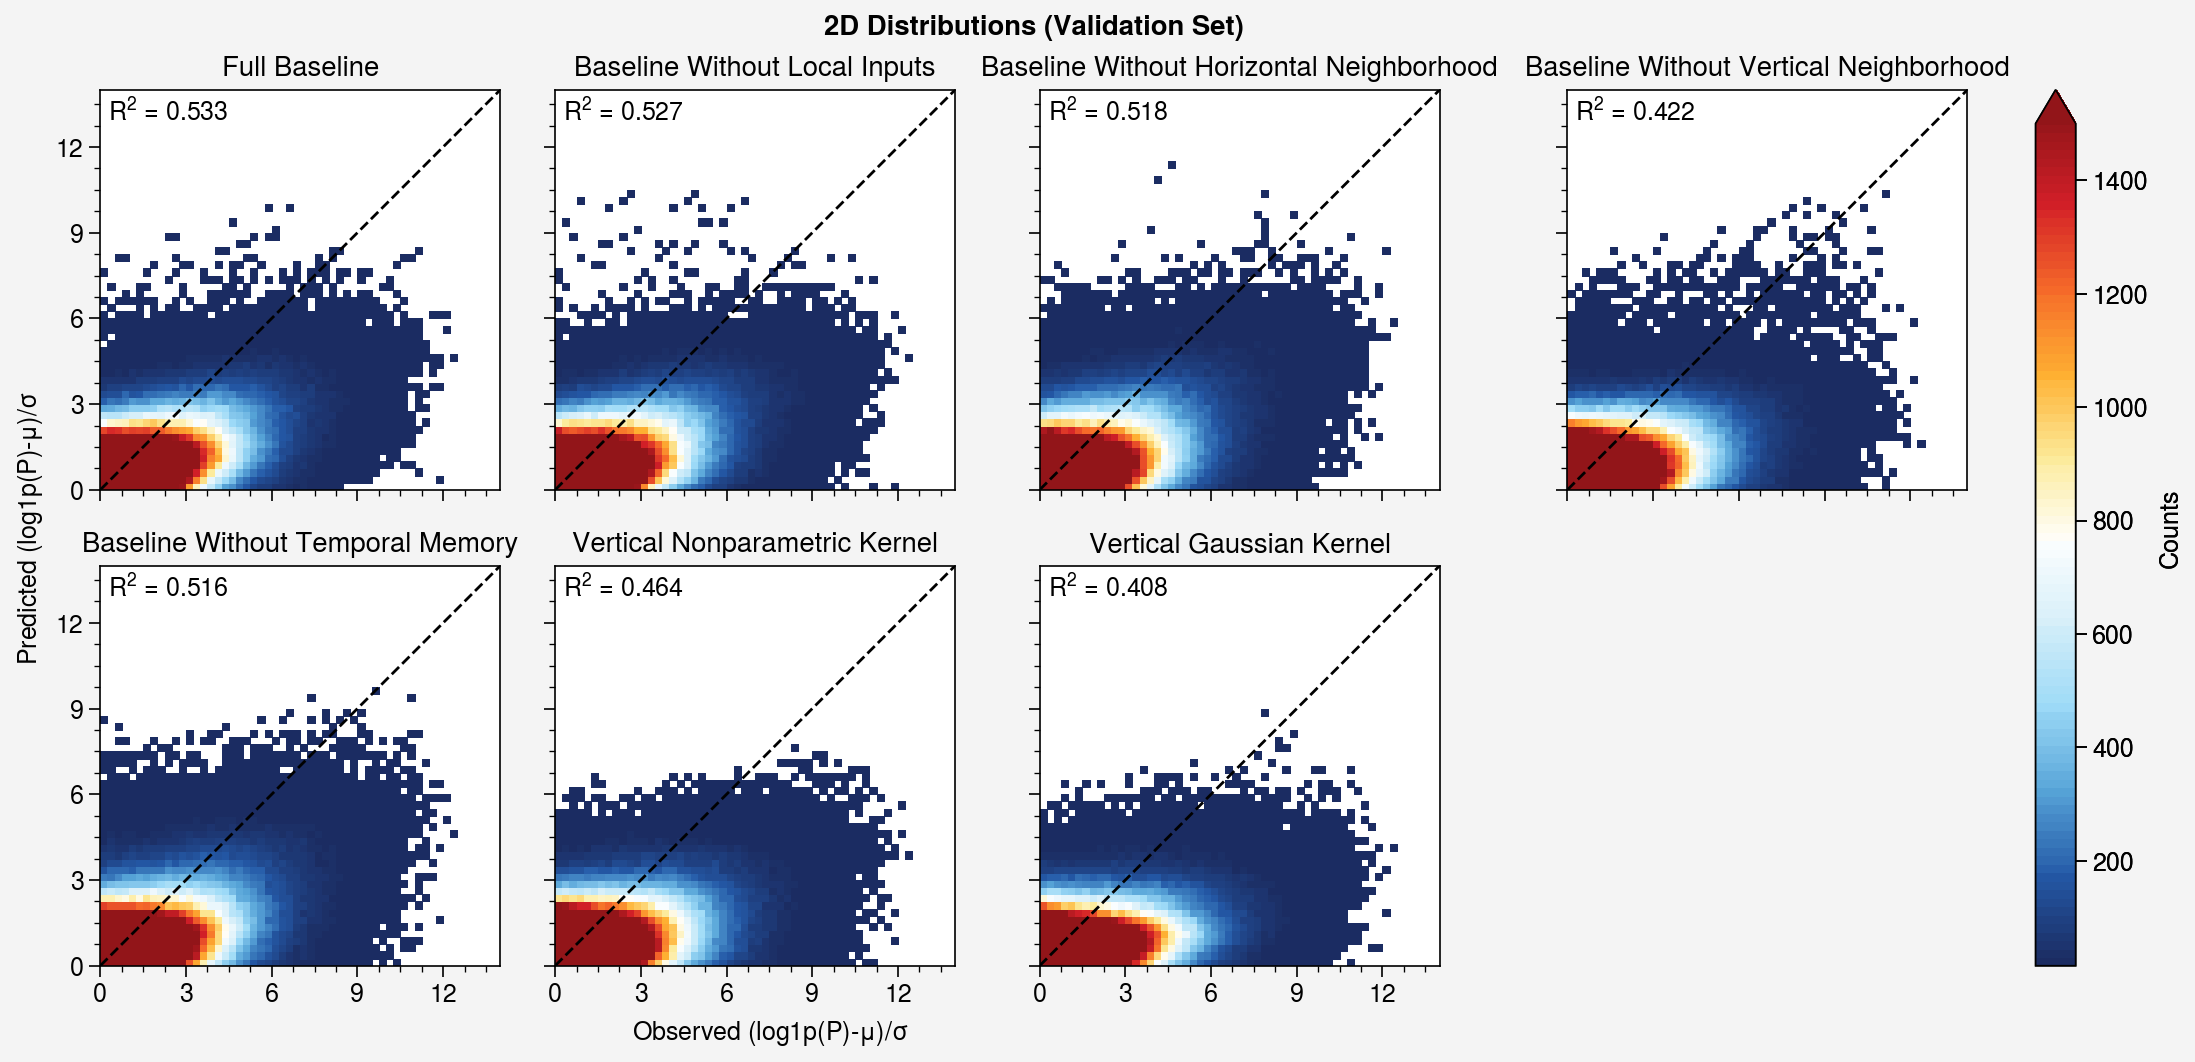

In [21]:
plot_density_panels(results,nrows=nrows,ncols=ncols)

In [26]:
# plot_confusion_matrix(results,nrows=nrows,ncols=ncols)

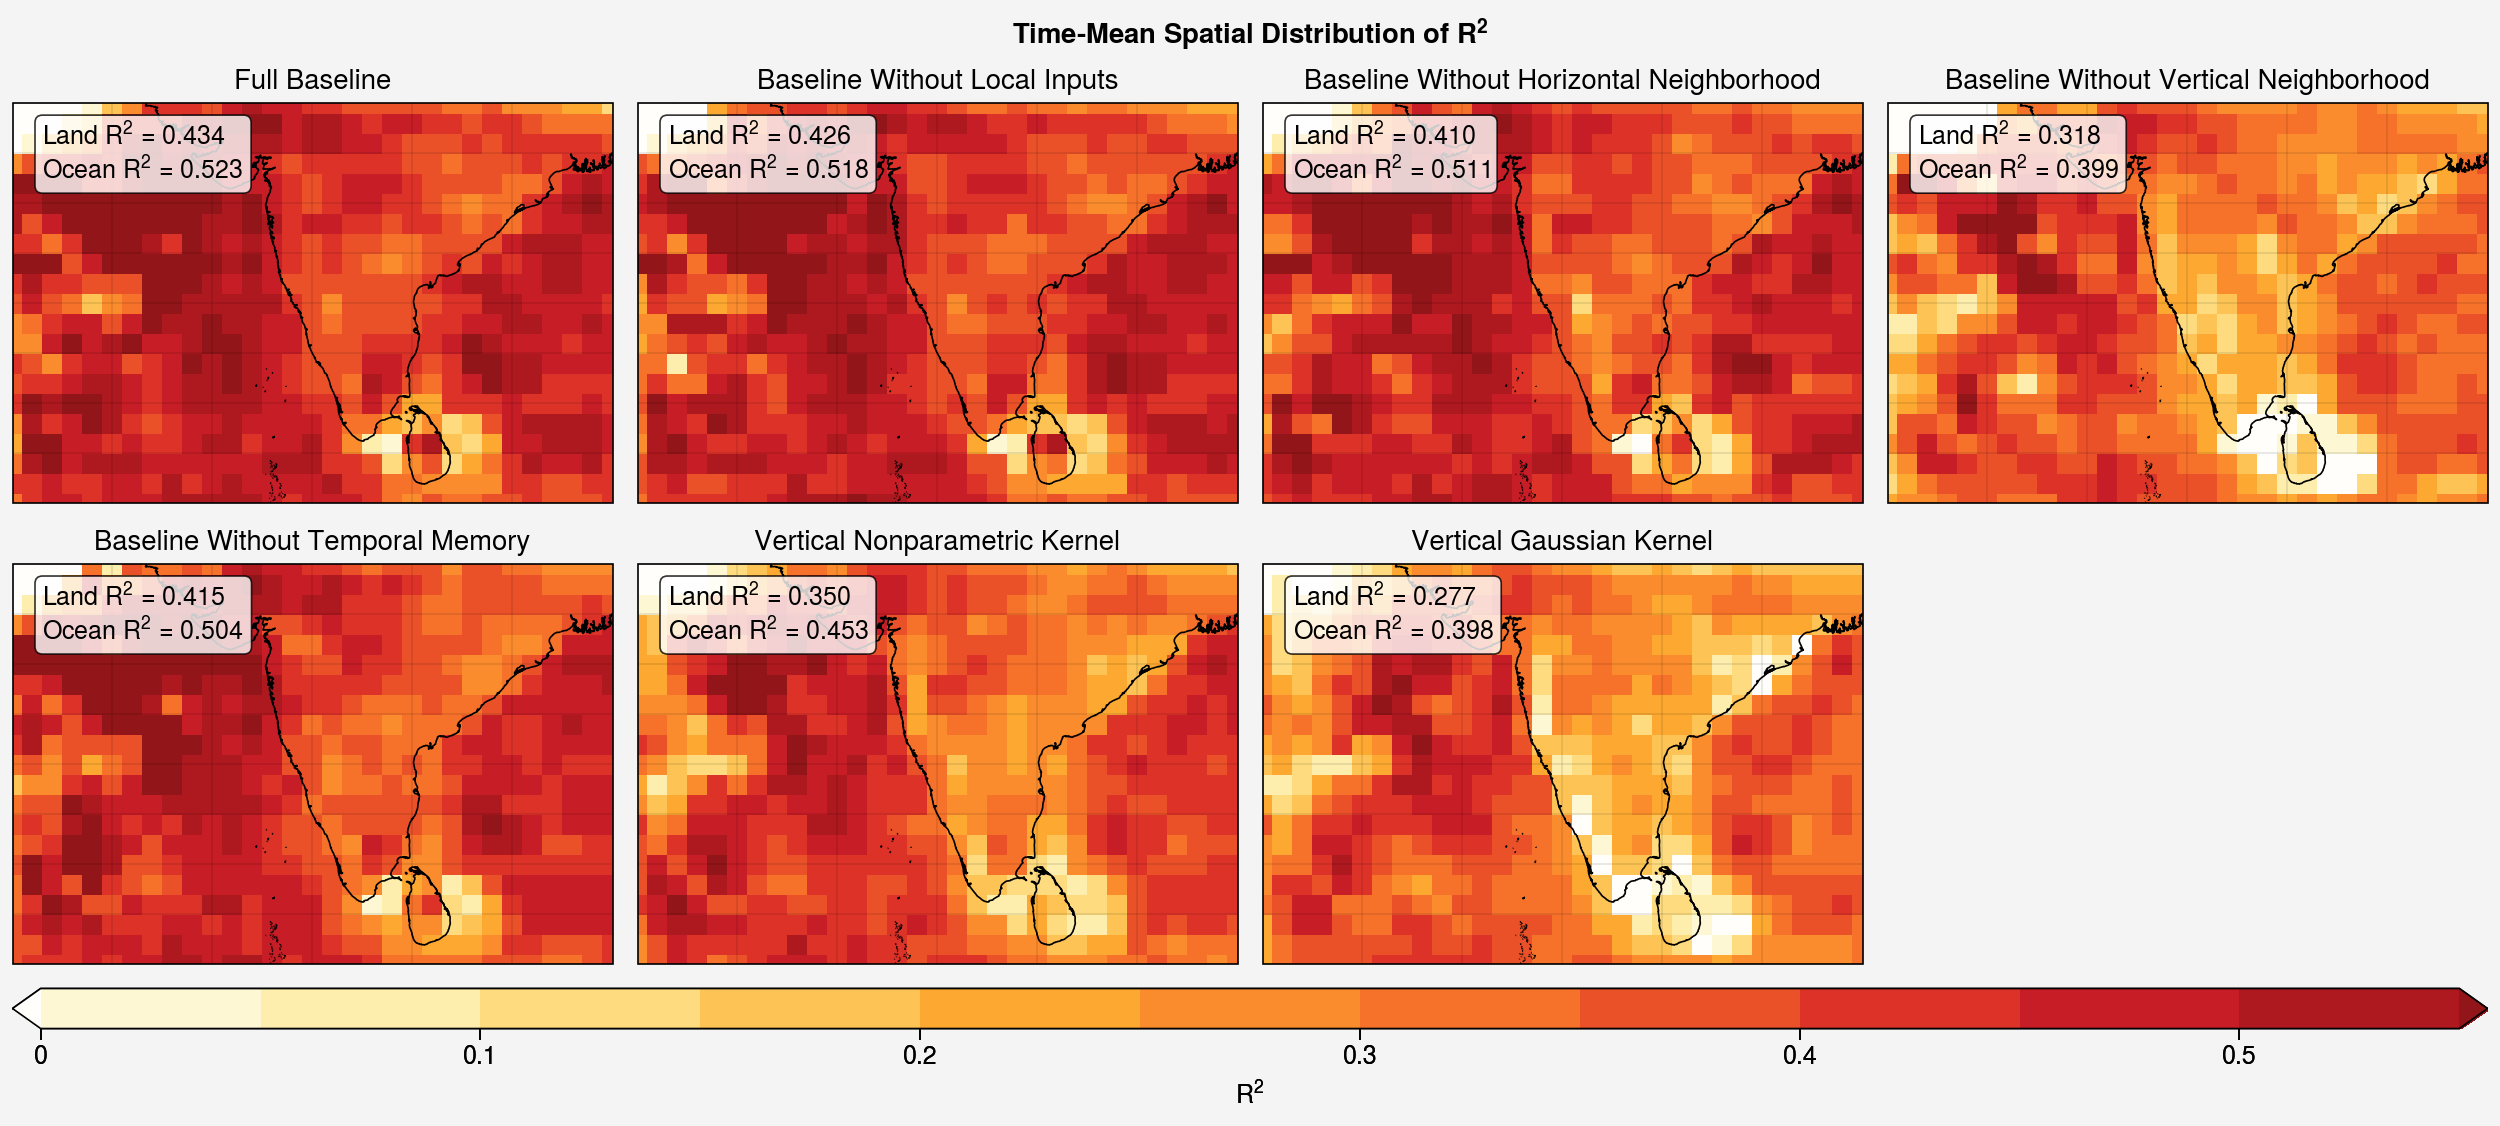

In [23]:
plot_r2_maps(results,nrows=nrows,ncols=ncols,landfrac=landfrac)

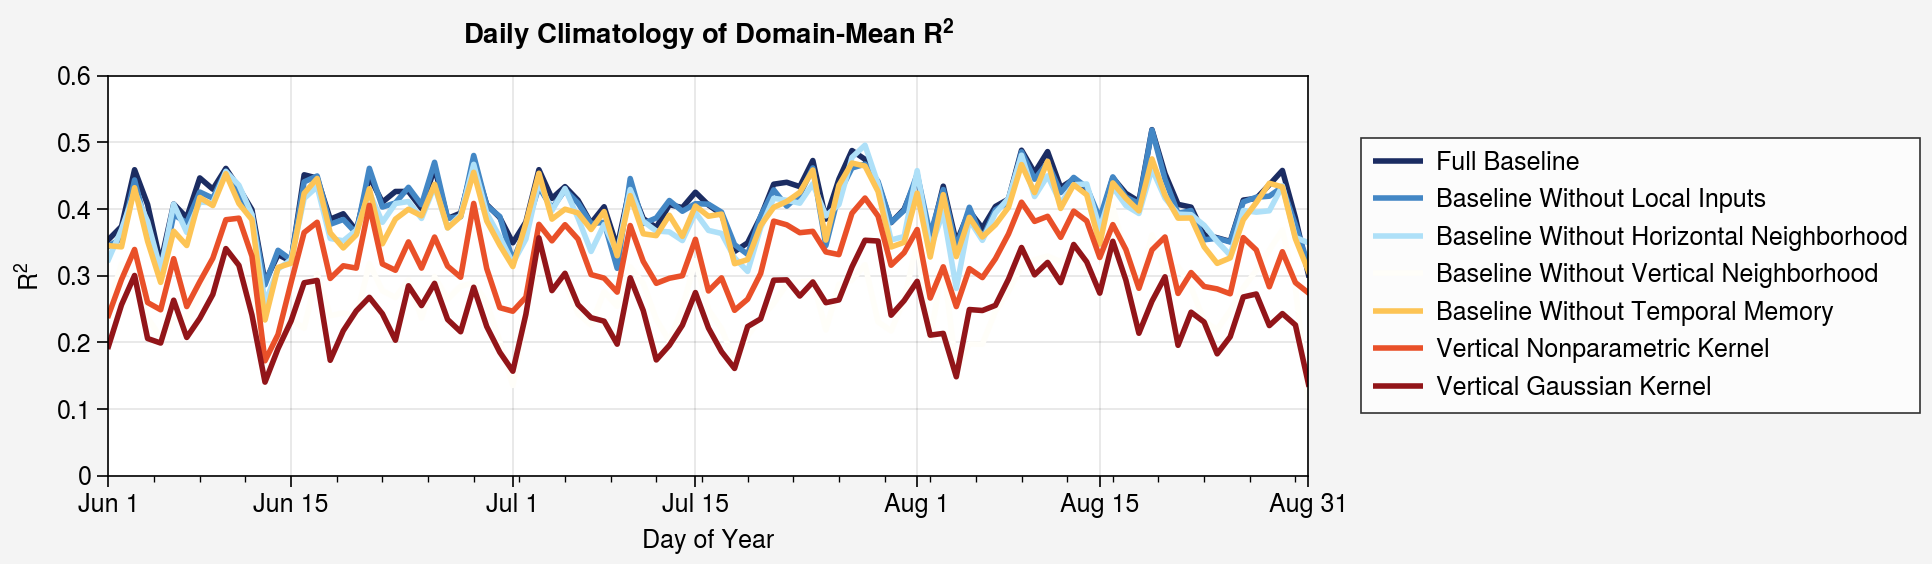

In [24]:
plot_r2_doy(results)

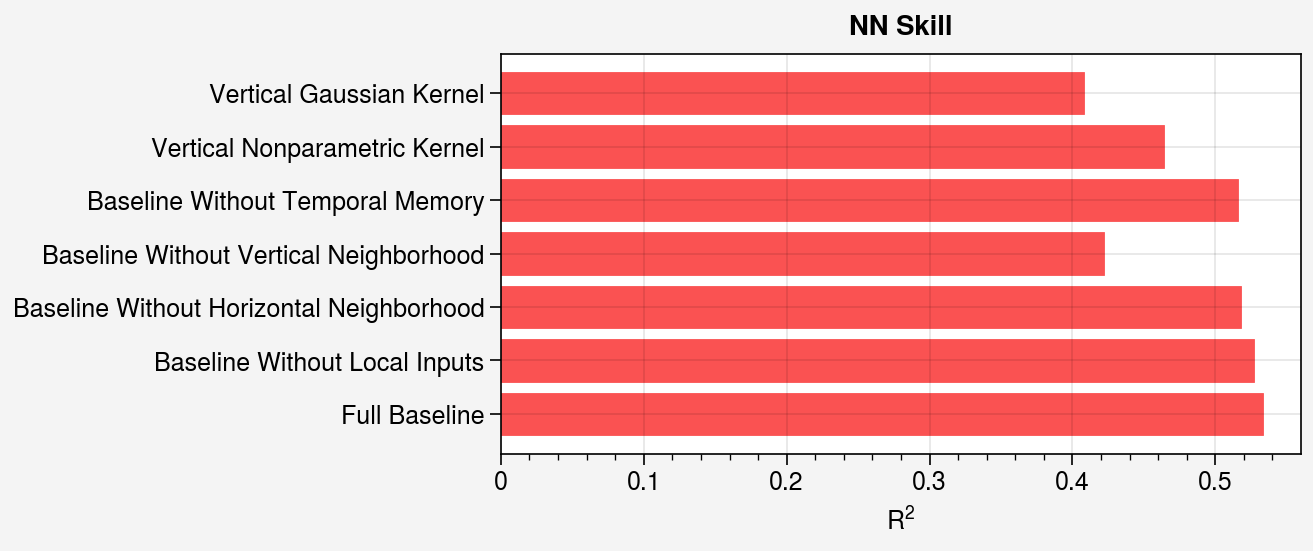

In [25]:
plot_r2_bars(results)